<a href="https://colab.research.google.com/github/AliceNanL/BA820-project/blob/Childcare_Cost_EDA/BA820_Childcare_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **B1 Team 11**
## Childcare EDA — Anna Wei, Nan Li, Pin-Chen Kuo, Stephanie Chen

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

childcare_costs = pd.read_csv(
    '/content/drive/MyDrive/Colab Notebooks/BA820/childcare_costs.csv'
)

counties = pd.read_csv(
    '/content/drive/MyDrive/Colab Notebooks/BA820/counties.csv'
)

In [ ]:
print(childcare_costs.head())
print(counties.head())

   county_fips_code  study_year  unr_16  funr_16  munr_16  unr_20to64  \
0              1001        2008    5.42     4.41     6.32         4.6   
1              1001        2009    5.93     5.72     6.11         4.8   
2              1001        2010    6.21     5.57     6.78         5.1   
3              1001        2011    7.55     8.13     7.03         6.2   
4              1001        2012    8.60     8.88     8.29         6.7   

   funr_20to64  munr_20to64  flfpr_20to64  flfpr_20to64_under6  ...  memp_p  \
0          3.5          5.6          68.9                 66.9  ...   21.55   
1          4.6          5.0          70.8                 63.7  ...   21.96   
2          4.6          5.6          71.3                 67.0  ...   21.28   
3          6.3          6.1          70.2                 66.5  ...   22.80   
4          6.4          7.0          70.6                 67.1  ...   22.88   

   femp_p   mcsa  mfccsa  mc_infant  mc_toddler  mc_preschool  mfcc_infant  \
0    4.0

In [ ]:
childcare_costs['county_fips_code'] = childcare_costs['county_fips_code'].astype(str)
counties['county_fips_code'] = counties['county_fips_code'].astype(str)

merged_df = pd.merge(
    childcare_costs,
    counties,
    on='county_fips_code',
    how='inner'
)

#**Merged Data EDA**

In [ ]:
merged_df['_merge'] = pd.merge(
    childcare_costs,
    counties,
    on='county_fips_code',
    how='inner',
    indicator=True
)['_merge']

merged_df['_merge'].value_counts()

,count
_merge,
both,34567
left_only,0
right_only,0


In [ ]:
merged_df.to_csv(
    '/content/drive/MyDrive/Colab Notebooks/BA820/childcare_cost_with_counties.csv',
    index=False
)

In [ ]:
merged_df.shape

(34567, 65)

In [ ]:
merged_df.head()

,county_fips_code,study_year,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,...,mc_infant,mc_toddler,mc_preschool,mfcc_infant,mfcc_toddler,mfcc_preschool,county_name,state_name,state_abbreviation,_merge
0,1001,2008,5.42,4.41,6.32,4.6,3.5,5.6,68.9,66.9,...,104.95,104.95,85.92,83.45,83.45,81.40,Autauga County,Alabama,AL,both
1,1001,2009,5.93,5.72,6.11,4.8,4.6,5.0,70.8,63.7,...,105.11,105.11,87.59,87.39,87.39,85.68,Autauga County,Alabama,AL,both
2,1001,2010,6.21,5.57,6.78,5.1,4.6,5.6,71.3,67.0,...,105.28,105.28,89.26,91.33,91.33,89.96,Autauga County,Alabama,AL,both
3,1001,2011,7.55,8.13,7.03,6.2,6.3,6.1,70.2,66.5,...,105.45,105.45,90.93,95.28,95.28,94.25,Autauga County,Alabama,AL,both
4,1001,2012,8.60,8.88,8.29,6.7,6.4,7.0,70.6,67.1,...,105.61,105.61,92.60,99.22,99.22,98.53,Autauga County,Alabama,AL,both


In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34567 entries, 0 to 34566
Data columns (total 65 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   county_fips_code           34567 non-null  object  
 1   study_year                 34567 non-null  int64   
 2   unr_16                     34567 non-null  float64 
 3   funr_16                    34567 non-null  float64 
 4   munr_16                    34567 non-null  float64 
 5   unr_20to64                 34567 non-null  float64 
 6   funr_20to64                34567 non-null  float64 
 7   munr_20to64                34567 non-null  float64 
 8   flfpr_20to64               34567 non-null  float64 
 9   flfpr_20to64_under6        34567 non-null  float64 
 10  flfpr_20to64_6to17         34567 non-null  float64 
 11  flfpr_20to64_under6_6to17  34567 non-null  float64 
 12  mlfpr_20to64               34567 non-null  float64 
 13  pr_f                       3456

We can see that the attributes: mcsa, mfccsa, mc_infant, mc_toddler, mc_preschool, mfcc_infant, mfcc_toddler, mfcc_preschool all have some missing values.

In [ ]:
merged_df.isnull().sum()

,0
county_fips_code,0
study_year,0
unr_16,0
funr_16,0
munr_16,0
...,...
mfcc_preschool,11184
county_name,0
state_name,0
state_abbreviation,0


In [ ]:
merged_df.describe()

,study_year,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,flfpr_20to64_6to17,...,memp_p,femp_p,mcsa,mfccsa,mc_infant,mc_toddler,mc_preschool,mfcc_infant,mfcc_toddler,mfcc_preschool
count,34567.000000,34567.000000,34567.00000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,...,34567.000000,34567.000000,23593.000000,23383.000000,23593.000000,23593.000000,23593.000000,23383.000000,23383.000000,23383.000000
mean,2012.999711,7.465902,7.02902,7.860291,6.900073,6.482007,7.275457,70.086125,68.821409,78.824106,...,23.456238,7.634403,101.234253,92.523582,146.051770,130.482768,122.232852,113.421657,106.759749,104.189510
std,3.162232,3.538619,3.56342,4.037657,3.446199,3.477956,3.990758,7.696499,11.758088,8.529813,...,7.956927,4.501044,34.552888,27.669904,53.698566,43.775370,38.538323,32.819372,29.982431,28.961701
min,2008.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,33.600000,0.000000,0.000000,...,0.000000,0.000000,18.980000,22.000000,27.730000,21.540000,21.540000,43.080000,43.080000,40.030000
25%,2010.000000,5.100000,4.64000,5.200000,4.600000,4.200000,4.700000,65.100000,62.600000,74.400000,...,17.610000,4.410000,78.650000,75.000000,108.750000,100.000000,95.880000,90.000000,85.085000,84.255000
50%,2013.000000,7.050000,6.59000,7.390000,6.500000,6.000000,6.800000,70.600000,69.600000,79.450000,...,23.400000,6.630000,96.530000,88.180000,134.500000,120.990000,113.990000,106.000000,100.250000,99.650000
75%,2016.000000,9.350000,8.88000,9.920000,8.700000,8.250000,9.200000,75.500000,76.100000,84.225000,...,28.930000,9.920000,119.380000,107.500000,166.330000,148.710000,139.300000,129.315000,124.950000,120.200000
max,2018.000000,36.110000,38.24000,39.740000,33.900000,44.500000,45.500000,100.000000,100.000000,100.000000,...,87.500000,66.480000,375.400000,308.000000,470.000000,419.000000,385.000000,430.940000,376.320000,331.340000


## **Gender Earning Gaps**

<Axes: >

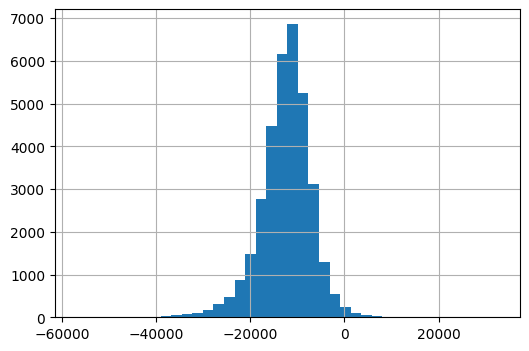

In [ ]:
merged_df['earnings_gap'] = merged_df['fme_2018'] - merged_df['mme_2018']
merged_df['earnings_gap'].hist(bins=40, figsize=(6,4))

There's an inequality in earnings distribution, with women earning less than men since the distribution is not centered at zero but towards large negative values.

## **Labor Fore Comparison**

<Axes: >

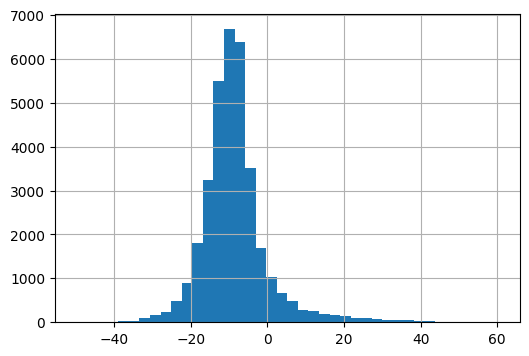

In [ ]:
merged_df['lfp_gap'] = merged_df['flfpr_20to64'] - merged_df['mlfpr_20to64']
merged_df['lfp_gap'].hist(bins=40, figsize=(6,4))

,lfp_child_gap
count,34567.000000
mean,-1.264716
std,10.052044
min,-77.000000
25%,-6.500000
50%,-1.500000
75%,4.100000
max,54.500000


**Labor force participation of the female population ages 20–64, ages 20–64 with children under 6, and ages 20–64 with children ages 6–17**

<Axes: >

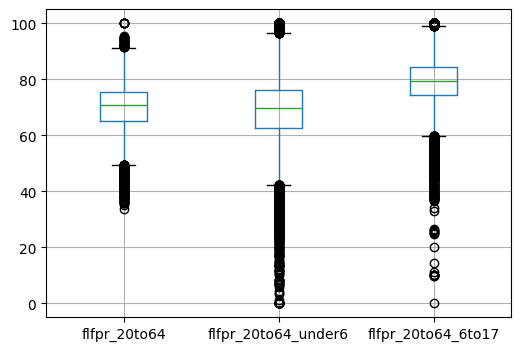

In [ ]:
merged_df[
    ['flfpr_20to64', 'flfpr_20to64_under6', 'flfpr_20to64_6to17']
].boxplot(figsize=(6,4))


The boxplots above indicate that from the three attributes, women ages 20-64 with children under 6 have the most outliers where there is very weak or no participation from them in the workforce.

# **Racial Demographics**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


demo_cols = [
    'one_race_w',
    'one_race_b',
    'one_race_i',
    'one_race_a',
    'one_race_h',
    'one_race_other',
    'two_races',
    'hispanic'
]


demo_means = merged_df[demo_cols].mean()

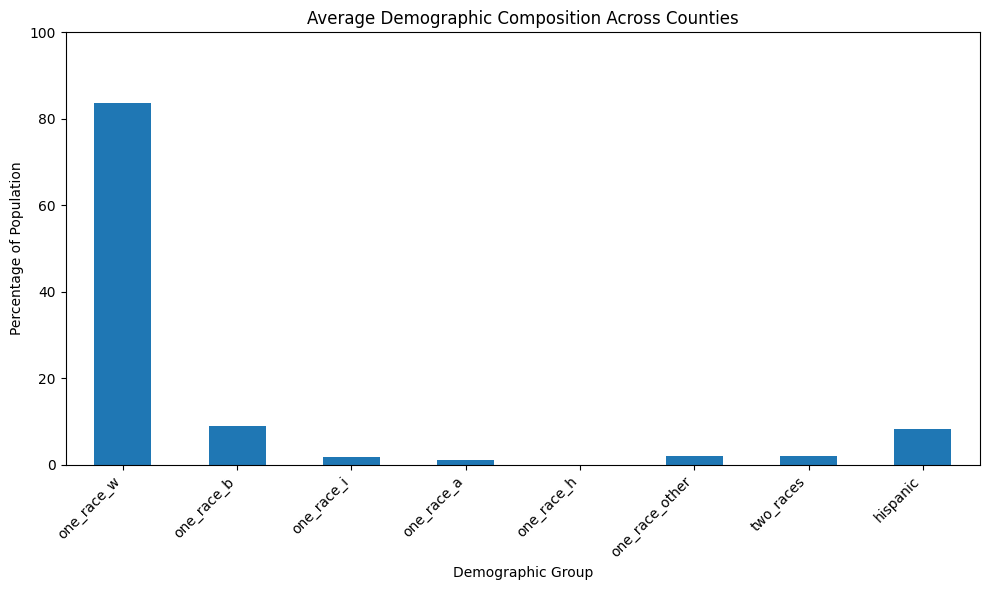

In [ ]:
plt.figure(figsize=(10,6))
demo_means.plot(kind='bar')

plt.title('Average Demographic Composition Across Counties')
plt.ylabel('Percentage of Population')
plt.xlabel('Demographic Group')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

# **Houeshold Composition**

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

household_cols = [
    'h_under6_both_work',
    'h_under6_f_work',
    'h_under6_m_work',
    'h_under6_single_m',
    'h_6to17_both_work',
    'h_6to17_fwork',
    'h_6to17_mwork',
    'h_6to17_single_m'
]

household_totals = merged_df[household_cols].sum()

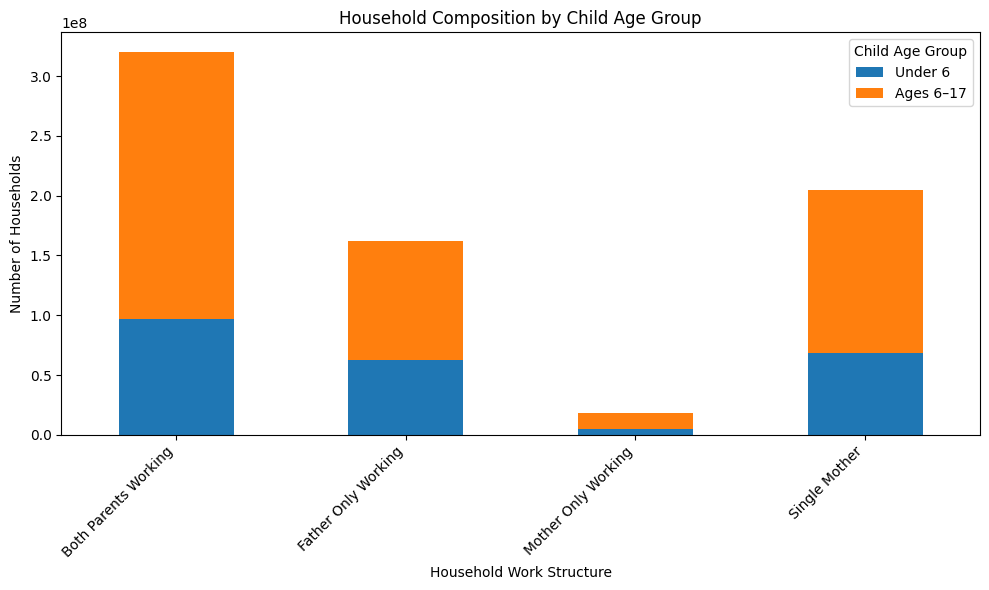

In [ ]:
household_df = pd.DataFrame({
    'Under 6': [
        household_totals['h_under6_both_work'],
        household_totals['h_under6_f_work'],
        household_totals['h_under6_m_work'],
        household_totals['h_under6_single_m']
    ],
    'Ages 6–17': [
        household_totals['h_6to17_both_work'],
        household_totals['h_6to17_fwork'],
        household_totals['h_6to17_mwork'],
        household_totals['h_6to17_single_m']
    ]
}, index=[
    'Both Parents Working',
    'Father Only Working',
    'Mother Only Working',
    'Single Mother'
])

household_df.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Household Composition by Child Age Group')
plt.ylabel('Number of Households')
plt.xlabel('Household Work Structure')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Child Age Group')
plt.tight_layout()
plt.show()


Households with children under six are less likely to have both parents working and more likely to rely on single-earner or single-mother arrangements, while households with children aged 6–17 are predominantly dual-earner, reflecting reduced childcare constraints as children reach school age. It is also important to note that father-only working households far outnumber mother-only working households in both age groups, highlighting persistent gender asymmetries in caregiving and labor force participation.

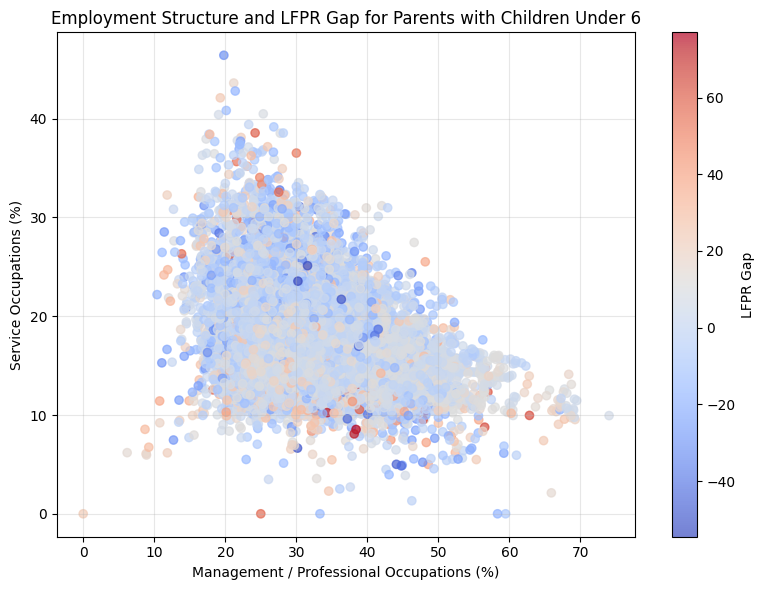

In [ ]:
import matplotlib.pyplot as plt

# Create LFPR gap
merged_df['lfpr_gap'] = (
    merged_df['flfpr_20to64'] - merged_df['flfpr_20to64_under6']
)

plt.figure(figsize=(8,6))

sc = plt.scatter(
    merged_df['emp_m'],
    merged_df['emp_service'],
    c=merged_df['lfpr_gap'],
    cmap = 'coolwarm',
    alpha=0.7
)

plt.xlabel('Management / Professional Occupations (%)')
plt.ylabel('Service Occupations (%)')
plt.title('Employment Structure and LFPR Gap for Parents with Children Under 6')

plt.colorbar(sc, label='LFPR Gap')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The plot above depicts the Labor Force Participation Rate Gap, where warmer colors indicate a larger gap and cooler colors showing a smaller gap. We can see that there is a greater constrain and larger LFPR gap for parents to stay in the larbor force in service occupations. In contrast, counties with a greater share of management and professional occupations generally show smaller participation gaps, suggesting that job flexibility, wages, and workplace supports may mitigate childcare-related labor market penalties.

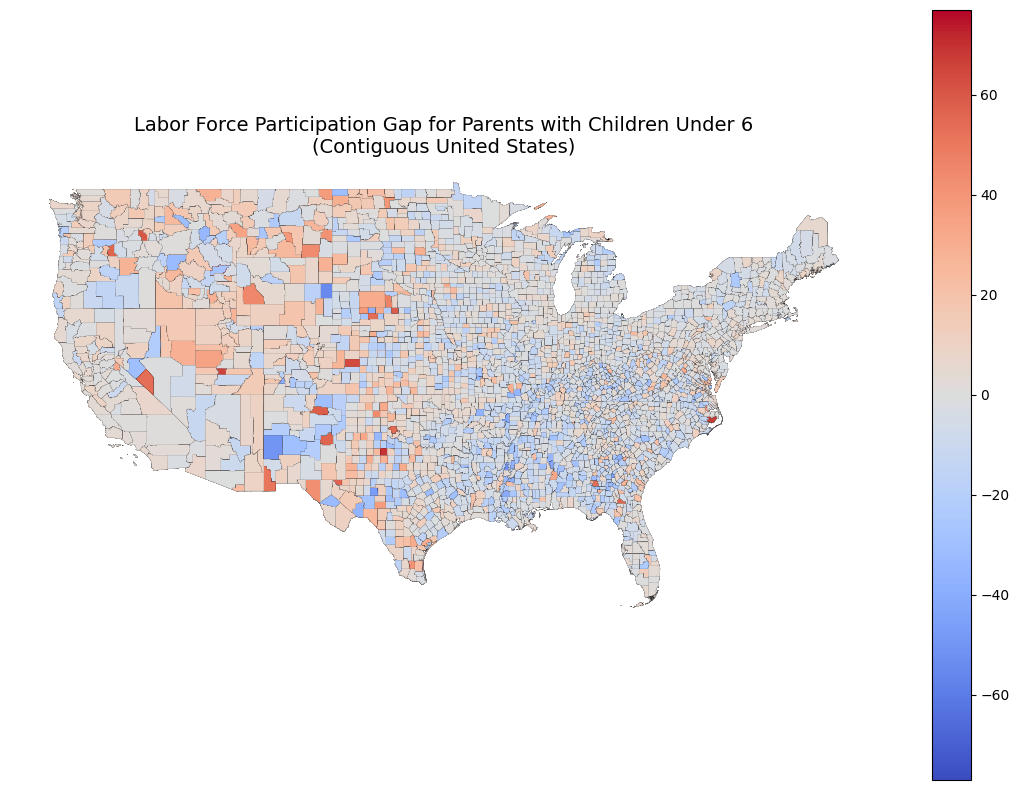

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

merged_df['lfpr_gap'] = (
    merged_df['flfpr_20to64'] - merged_df['flfpr_20to64_under6']
)

merged_df['county_fips_code'] = (
    merged_df['county_fips_code'].astype(str).str.zfill(5)
)


counties = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2021/shp/cb_2021_us_county_500k.zip"
)

counties['GEOID'] = counties['GEOID'].astype(str)


map_df = counties.merge(
    merged_df,
    left_on='GEOID',
    right_on='county_fips_code',
    how='left'
)


contiguous = map_df[
    ~map_df['STATEFP'].isin(['02', '15', '60', '66', '69', '72', '78'])
]


fig, ax = plt.subplots(1, 1, figsize=(14,10))


vmax = max(
    abs(contiguous['lfpr_gap'].min()),
    abs(contiguous['lfpr_gap'].max())
)

contiguous.plot(
    column='lfpr_gap',
    cmap='coolwarm',
    vmin=-vmax,
    vmax=vmax,
    linewidth=0.05,
    edgecolor='black',
    legend=True,
    ax=ax
)

ax.set_title(
    'Labor Force Participation Gap for Parents with Children Under 6\n(Contiguous United States)',
    fontsize=14
)
ax.axis('off')

plt.show()

The map reveals regional clustering in labor force participation gaps for parents with children under six. Larger gaps are more prevalent across parts of the Midwest and South, while smaller gaps are more common in Northern regions, along the West Coast, and in major metropolitan areas. This spatial pattern suggests that local labor market conditions and institutional supports play an important role in shaping parental labor force participation outcomes.

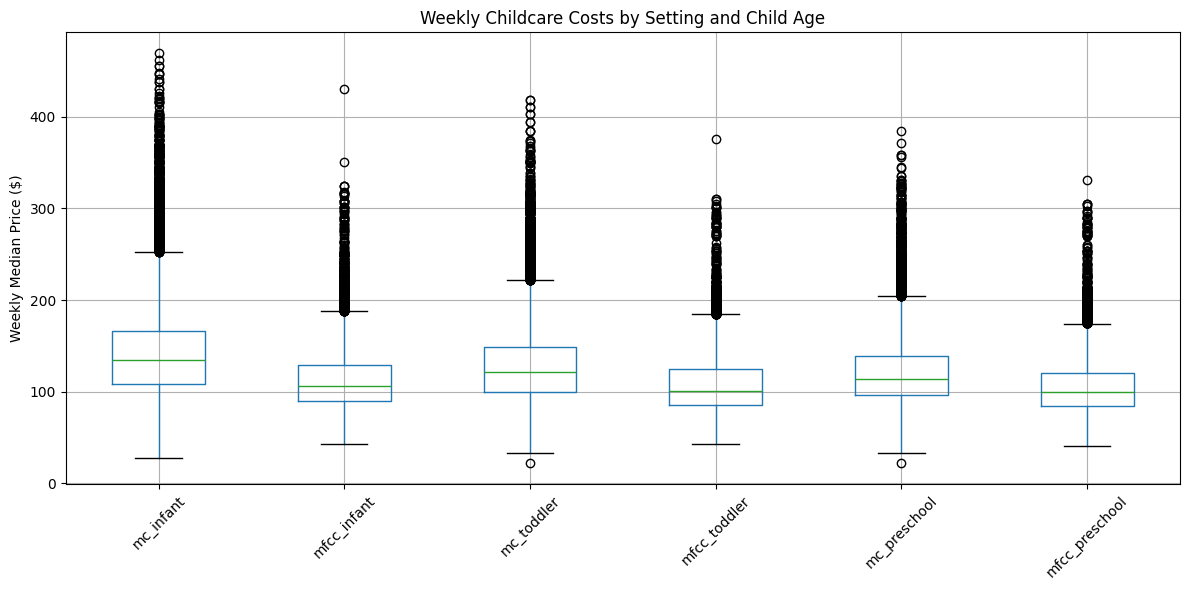

In [ ]:
import matplotlib.pyplot as plt

cols = [
    'mc_infant', 'mfcc_infant',
    'mc_toddler', 'mfcc_toddler',
    'mc_preschool', 'mfcc_preschool'
]

merged_df[cols].boxplot(figsize=(12,6), rot=45)

plt.title('Weekly Childcare Costs by Setting and Child Age')
plt.ylabel('Weekly Median Price ($)')
plt.tight_layout()
plt.show()


The boxplots above are comparing the weekly childcare cost distribution. The presence of high outliers indicates that childcare costs can be exceptionally high in certain counties(metropolitan places), particularly for infants and center-based care. While most counties fall within a more moderate cost range, this variation highlights substantial geographic inequality in childcare affordability, which may contribute to uneven labor force participation outcomes among parents with young children.